In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import numpy as np
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeFez
backend = FakeFez()
shots = 8192

#Credits to: https://qiskit.github.io/qiskit-aer/tutorials/2_device_noise_simulation.html

Results (Format: 'data syndrome'): {'0 11': 6222, '1 11': 1970}


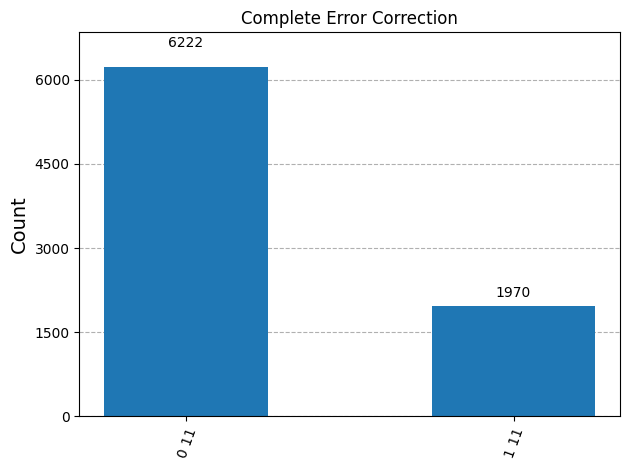

In [2]:
# 1. Register definition
q = QuantumRegister(3, 'q')
c_syndrome = ClassicalRegister(2, 'syndrome')
c_data = ClassicalRegister(1, 'data') 
circ = QuantumCircuit(q, c_syndrome, c_data, name = '3-qubit bit-flip code')

# 2. Initialization (Probabilities 3/4 and 1/4)
theta = np.pi / 3
circ.ry(theta, 0)

# 3. Logical qubit encoding
circ.cx(0, 1)
circ.cx(0, 2)
circ.barrier()

# 4. Error injection
circ.x(0)
circ.barrier()

# 5. Decoding
circ.cx(0, 1)
circ.cx(0, 2)
circ.barrier()

circ.measure([1, 2], c_syndrome)  # Measure the syndrome into the classical register

# 7. CONDITIONAL CORRECTION (Dynamic circuits)
# The condition is passed as a tuple: (classical_register, decimal_value)

with circ.if_test((c_syndrome, 3)):
    circ.x(0)  # If it measures '11' , correct q0

circ.barrier()

# 8. Final DATA measurement
circ.measure([0], c_data)     

# 9. Execution on the simulator
sim_ideal = AerSimulator()
result = sim_ideal.run(transpile(circ, sim_ideal), shots=8192).result()
counts = result.get_counts(circ)

print("Results (Format: 'data syndrome'):", counts)   
plot_histogram(counts, title='Complete Error Correction')
#circ.draw('mpl')

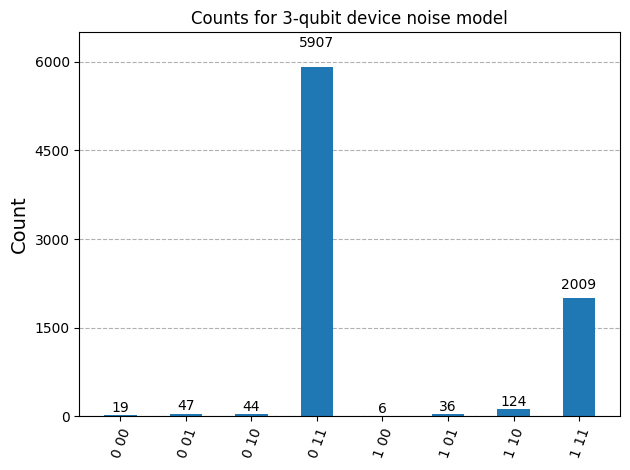

In [4]:
#Using the noise model from the fake Vigo device


noise = NoiseModel.from_backend(backend) 
#From mumbai backends we just extract the noise model, 
#so we can apply conditional corrections in the circuit, which is not possible when we execute directly on the backend, 
# #as it does not support dynamic circuits.
sim_noise = AerSimulator(noise_model = noise)



# Transpile the circuit for the noisy basis gates
tcirc = transpile(circ, sim_noise)

# Execute noisy simulation and get counts
result_noise = sim_noise.run(tcirc, shots=8192).result()
counts_noise = result_noise.get_counts(0)
plot_histogram(counts_noise,
               title="Counts for 3-qubit device noise model")

# Tomography for Z component

In [5]:
# 1. Register definition
q = QuantumRegister(3, 'q')
c_syndrome = ClassicalRegister(2, 'syndrome')
c_data = ClassicalRegister(1, 'data') 
circ = QuantumCircuit(q, c_syndrome, c_data, name='Bit Flip Code Tomography Z component')

# 2. Initialization (Probabilities 3/4 and 1/4)
theta = np.pi / 3
circ.ry(theta, 0)
# 3. Logical qubit encoding
circ.cx(0, 1)
circ.cx(0, 2)
circ.barrier()
# 4. Error injection
circ.x(0)
circ.barrier()
# 5. Decoding
circ.cx(0, 1)
circ.cx(0, 2)
circ.barrier()

# 6. Exclusive SYNDROME measurement
circ.measure([1, 2], c_syndrome) 
circ.barrier()

#6. Conditional Correction


with circ.if_test((c_syndrome, 3)):
    circ.x(0)  # If it measures '11' , correct q0

#For errors on q1 or q2, the correction is not applied cause q0 maintains without error.
circ.barrier()

#7. Tomography measurements for Z component
circ.measure([0], c_data)
circ.barrier()




# 6. Execution on the simulator
sim_ideal = AerSimulator()
result_z = sim_ideal.run(transpile(circ, sim_ideal), shots=8192).result()
counts_z = result_z.get_counts(circ)
print("Results (Format: 'data syndrome'):", counts_z)
fig1 = plot_histogram(counts_z, title='Tomography for Z component for bit-flip code on ideal simulator')
fig1.savefig('Tomography_comp_Z_bitflip.png')


Results (Format: 'data syndrome'): {'1 11': 2063, '0 11': 6129}


# Tomography for Z component at noisy model

In [6]:
# Transpile the circuit for the noisy basis gates
tcirc = transpile(circ, sim_noise)

# Execute noisy simulation and get counts
result_noise_z = sim_noise.run(tcirc, shots=8192).result()
counts_noise_z = result_noise_z.get_counts(0)
fig2 = plot_histogram(counts_noise_z,
               title="Tomography for Z component for bit-flip code on noisy model")
fig2.savefig('Tomography_comp_Z_noisy_bitflip.png')

# Tomography for X component

In [7]:
# TOMOGRAFÍA PARA LA COMPONENTE Z

# 1. Register definition
q = QuantumRegister(3, 'q')
c_syndrome = ClassicalRegister(2, 'syndrome')
c_data = ClassicalRegister(1, 'data') 
circ = QuantumCircuit(q, c_syndrome, c_data, name='Bit Flip Code Tomography X component')

# 2. Initialization (Probabilities 3/4 and 1/4)
theta = np.pi / 3
circ.ry(theta, 0)
# 3. Logical qubit encoding
circ.cx(0, 1)
circ.cx(0, 2)
circ.barrier()
# 4. Error injection
circ.x(0)
circ.barrier()
# 5. Decoding
circ.cx(0, 1)
circ.cx(0, 2)
circ.barrier()

# 6. Exclusive SYNDROME measurement
circ.measure([1, 2], c_syndrome) 
circ.barrier()

#6. Conditional Correction


with circ.if_test((c_syndrome, 3)):
    circ.x(0)  # If it measures '11' , correct q0

#For errors on q1 or q2, the correction is not applied cause q0 maintains without error.
circ.barrier()

#7. Tomography measurements for X component
circ.h(0)  # Apply H to measure in X basis
circ.measure([0], c_data)
circ.barrier()




# 6. Execution on the simulator
sim_ideal = AerSimulator()
result_x = sim_ideal.run(transpile(circ, sim_ideal), shots=8192).result()
counts_x = result_x.get_counts(circ)
print("Results (Format: 'data syndrome'):", counts_x)
fig3 = plot_histogram(counts_x, title='Tomography for X component for bit-flip code on ideal simulator')
fig3.savefig('Tomography_comp_X_bitflip.png')


Results (Format: 'data syndrome'): {'0 11': 7586, '1 11': 606}


# Tomography for X-component at nosiy model

In [8]:
# Transpile the circuit for the noisy basis gates
tcirc = transpile(circ, sim_noise)

# Execute noisy simulation and get counts
result_noise_x = sim_noise.run(tcirc, shots=8192).result()
counts_noise_x = result_noise_x.get_counts(0)
fig4 = plot_histogram(counts_noise_x,
               title="Tomography for X component for bit-flip code on noisy model")
fig4.savefig('Tomography_comp_X_noisy_bitflip.png')

# Tomography for Y-basis

In [9]:
# TOMOGRAFÍA PARA LA COMPONENTE Z

# 1. Register definition
q = QuantumRegister(3, 'q')
c_syndrome = ClassicalRegister(2, 'syndrome')
c_data = ClassicalRegister(1, 'data') 
circ = QuantumCircuit(q, c_syndrome, c_data, name='Bit Flip Code Tomography Y component')

# 2. Initialization (Probabilities 3/4 and 1/4)
theta = np.pi / 3
circ.ry(theta, 0)
# 3. Logical qubit encoding
circ.cx(0, 1)
circ.cx(0, 2)
circ.barrier()
# 4. Error injection
circ.x(0)
circ.barrier()
# 5. Decoding
circ.cx(0, 1)
circ.cx(0, 2)
circ.barrier()

# 6. Exclusive SYNDROME measurement
circ.measure([1, 2], c_syndrome) 
circ.barrier()

#6. Conditional Correction


with circ.if_test((c_syndrome, 3)):
    circ.x(0)  # If it measures '11' , correct q0

#For errors on q1 or q2, the correction is not applied cause q0 maintains without error.
circ.barrier()

#7. Tomography measurements for Y component
circ.sdg(0)  # Apply Sdg to measure in Y basis
circ.h(0)  
circ.measure([0], c_data)
circ.barrier()




# 6. Execution on the simulator
sim_ideal = AerSimulator()
result_y = sim_ideal.run(transpile(circ, sim_ideal), shots=8192).result()
counts_y = result_y.get_counts(circ)
print("Results (Format: 'data syndrome'):", counts_y)
fig5 = plot_histogram(counts_y, title='Tomography for Y component for bit-flip code on ideal simulator')
fig5.savefig('Tomography_comp_Y_bitflip.png')


Results (Format: 'data syndrome'): {'0 11': 4089, '1 11': 4103}


# Tomography for Y-component at noisy model

In [10]:
# Transpile the circuit for the noisy basis gates
tcirc = transpile(circ, sim_noise)

# Execute noisy simulation and get counts
result_noise_y = sim_noise.run(tcirc, shots=8192).result()
counts_noise_y = result_noise_y.get_counts(0)
fig6 = plot_histogram(counts_noise_y,
               title="Tomography for Y component for bit-flip code on noisy model")
fig6.savefig('Tomography_comp_Y_noisy_bitflip.png')

# State vector representation at the Bloch sphere

Mean value for Z component: 0.496337890625
Mean value for X component: 0.85205078125
Mean value for Y component: -0.001708984375
Probability conservation (should be close to 1.0): 0.9723447561264038


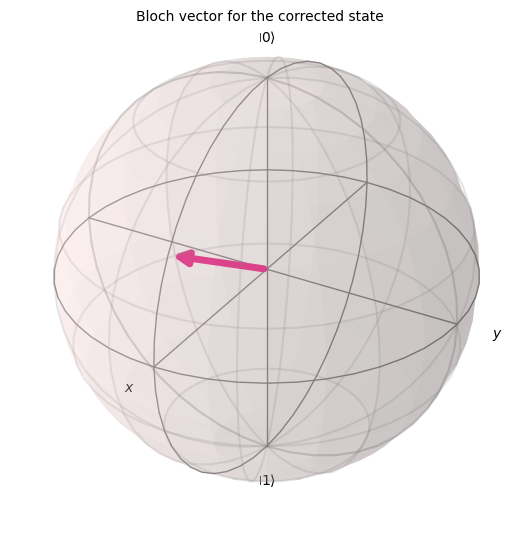

In [11]:
from qiskit.visualization import plot_bloch_vector
import numpy as np

shots = 8192


# Direct extraction and calculation for the Z component

counts_0_z = sum(val for key, val in counts_z.items() if key.startswith('0'))
counts_1_z = sum(val for key, val in counts_z.items() if key.startswith('1'))
mean_z = (counts_0_z - counts_1_z) / shots


# Direct extraction and calculation for the X component

counts_0_x = sum(val for key, val in counts_x.items() if key.startswith('0'))
counts_1_x = sum(val for key, val in counts_x.items() if key.startswith('1'))
mean_x = (counts_0_x - counts_1_x) / shots


# Direct extraction and calculation for the Y component

counts_0_y = sum(val for key, val in counts_y.items() if key.startswith('0'))
counts_1_y = sum(val for key, val in counts_y.items() if key.startswith('1'))
mean_y = (counts_0_y - counts_1_y) / shots

# Print the results
print(f"Mean value for Z component: {mean_z}")
print(f"Mean value for X component: {mean_x}")
print(f"Mean value for Y component: {mean_y}")

# Verify probability conservation
prob = mean_x ** 2 + mean_y ** 2 + mean_z ** 2
print(f"Probability conservation (should be close to 1.0): {prob}")

# Plot the Bloch vector
vector = np.array([mean_x, mean_y, mean_z])
plot_bloch_vector(vector, title='Bloch vector for the corrected state')

# Noisy bloch sphere representation

Mean value for Z component: 0.45556640625
Mean value for X component: 0.815185546875
Mean value for Y component: -0.00537109375
Probability conservation (should be close to 1.0): 0.8720970749855042


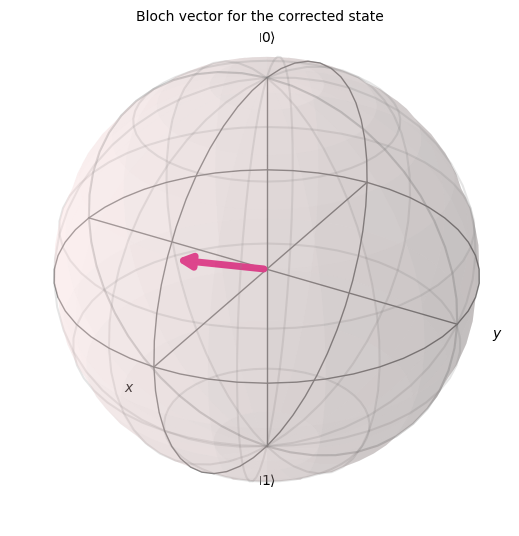

In [12]:
from qiskit.visualization import plot_bloch_vector
import numpy as np

shots = 8192


# Direct extraction and calculation for the Z component

counts_0_noise_z = sum(val for key, val in counts_noise_z.items() if key.startswith('0'))
counts_1_noise_z = sum(val for key, val in counts_noise_z.items() if key.startswith('1'))
mean_noise_z = (counts_0_noise_z - counts_1_noise_z) / shots


# Direct extraction and calculation for the X component

counts_0_noise_x = sum(val for key, val in counts_noise_x.items() if key.startswith('0'))
counts_1_noise_x = sum(val for key, val in counts_noise_x.items() if key.startswith('1'))
mean_noise_x = (counts_0_noise_x - counts_1_noise_x) / shots


# Direct extraction and calculation for the Y component

counts_0_noise_y = sum(val for key, val in counts_noise_y.items() if key.startswith('0'))
counts_1_noise_y = sum(val for key, val in counts_noise_y.items() if key.startswith('1'))
mean_noise_y = (counts_0_noise_y - counts_1_noise_y) / shots

# Print the results
print(f"Mean value for Z component: {mean_noise_z}")
print(f"Mean value for X component: {mean_noise_x}")
print(f"Mean value for Y component: {mean_noise_y}")

# Verify probability conservation
prob = mean_noise_x ** 2 + mean_noise_y ** 2 + mean_noise_z ** 2
print(f"Probability conservation (should be close to 1.0): {prob}")

# Plot the Bloch vector
vector = np.array([mean_noise_x, mean_noise_y, mean_noise_z])
plot_bloch_vector(vector, title='Bloch vector for the corrected state')

# Fidelity calculation for ideal model

In [13]:
# Density matrix reconstruction from the measured Bloch vector components
rho_reconstructed = 0.5 * (
    np.eye(2) +
    mean_x * np.array([[0,1],[1,0]]) +
    mean_y * np.array([[0,-1j],[1j,0]]) +
    mean_z * np.array([[1,0],[0,-1]])
)

# Ideal state as a density matrix vector
ideal = np.array([np.sqrt(3)/2, 1/2])
rho_ideal = np.outer(ideal, ideal)

# Fidelidad F = Tr(rho_ideal @ rho_reconstructed)
# Para estado puro: F = <psi|rho|psi>
fidelity = np.real(np.trace(rho_ideal @ rho_reconstructed))
print(f"Fidelidad reconstruida: {fidelity:.6f}")

Fidelidad reconstruida: 0.993033


# Fidelity calculation for noise model

In [14]:
# Density matrix reconstruction from the measured Bloch vector components
rho_reconstructed = 0.5 * (
    np.eye(2) +
    mean_noise_x * np.array([[0,1],[1,0]]) +
    mean_noise_y * np.array([[0,-1j],[1j,0]]) +
    mean_noise_z * np.array([[1,0],[0,-1]])
)

# Ideal state as a density matrix vector
ideal = np.array([np.sqrt(3)/2, 1/2])
rho_ideal = np.outer(ideal, ideal)

# Fidelidad F = Tr(rho_ideal @ rho_reconstructed)
# Para estado puro: F = <psi|rho|psi>
fidelity = np.real(np.trace(rho_ideal @ rho_reconstructed))
print(f"Fidelidad reconstruida: {fidelity:.6f}")

Fidelidad reconstruida: 0.966877
